# NFL Sports Betting Prediction on Binary Win / Loss

This notebook builds a graph based NFL prediction model using a GraphSAGE encoder and an MLP edge predictor.  
The task is binary: predict whether the **home team wins** each game or not (0 > 1)

- Data source: [Aussportsbetting.com NFL historical data](https://docs.google.com/spreadsheets/d/1LObox68UxXi3oQfEsWDqDBN8QNzbVX5W/edit?usp=drive_link&ouid=116021263276656483391&rtpof=true&sd=true)
- Graph:
  - Nodes: teams
  - Directed edges: games (home -> away)
  - Edge features: standardized closing odds
- Model:
  - Learnable team embeddings
  - 2 layer GraphSAGE encoder
  - MLP edge predictor
- Training:
  - Temporal split by date (70% train, 15% validate, 15% test)
  - Binary cross entropy loss with logits
  - Early stopping on validation loss
- Calibration and backtest:
  - Temperature scaling on validation logits
  - Backtest on test set using closing odds
  - Metrics, tables, and plots are saved for the final report


# REQUIREMENTS

In [ ]:
import torch
from google.colab import files

!pip freeze > requirements.txt

# Download the file to your local machine
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 1 - Data formatting & Graph construction


In [ ]:
# Install matching PyG wheels
import torch
print("Torch version:", torch.__version__)

!pip install --quiet torch torchvision torchaudio
!pip install --quiet torch-geometric
!pip install --quiet scikit-learn matplotlib pandas tqdm

# Install openpyxl so pandas can read Excel
!pip install -q openpyxl


Torch version: 2.8.0+cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00


In [ ]:
# Core imports and data loading

import os
import math
import time
import numpy as np
import pandas as pd
import random
import numpy as np
import torch




from torch_geometric.data import Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------
# Mount Google drive and load excel
# ------------------------------
from google.colab import drive
drive.mount("/content/drive")

# MUST HAVE this file in drive
excel_path = "/content/drive/MyDrive/nfl.xlsx"

# Load data
games_df = pd.read_excel(excel_path, engine="openpyxl")

print("Loaded games shape:", games_df.shape)
print("Columns:", list(games_df.columns))

games_df["Date"] = pd.to_datetime(games_df["Date"])
games_df["home_win"] = (games_df["Home Score"] > games_df["Away Score"]).astype(int)

print("Label distribution (home_win):")
print(games_df["home_win"].value_counts())


Using device: cuda


ValueError: mount failed

In [ ]:
# ------------------------------
# Build node set of teams
# ------------------------------

# Collect all unique team names from home and away columns
teams = sorted(set(games_df["Home Team"]).union(set(games_df["Away Team"])))
team_id_map = {team: idx for idx, team in enumerate(teams)}
num_nodes = len(teams)

print("Number of unique teams (nodes):", num_nodes)
print("First 10 team mappings:", list(team_id_map.items())[:10])

# ------------------------------
# Build edges (home -> Away)
# Each row= one game = one directed edge
# ------------------------------
home_ids = games_df["Home Team"].map(team_id_map).values
away_ids = games_df["Away Team"].map(team_id_map).values

edge_index = torch.tensor(
    [home_ids, away_ids],  # Edge index: shape [2, num_edges]
    dtype=torch.long
)

print("edge_index shape:", edge_index.shape)

# ------------------------------
# Raw edge attributes (closing odds) for later scaling
# ------------------------------
edge_attr_raw = games_df[["Home Odds Close", "Away Odds Close"]].values.astype(float)
edge_attr = torch.tensor(edge_attr_raw, dtype=torch.float32)

print("edge_attr shape:", edge_attr.shape)

# ------------------------------
# Edge level labels: 1 if home wins 0 if away wins
# ------------------------------
labels = games_df["home_win"].values.astype(int)
y = torch.tensor(labels, dtype=torch.long)
print("y shape:", y.shape)

# Store original odds as numpy arrays for backtest use
orig_home_odds = games_df["Home Odds Close"].values.astype(float)
orig_away_odds = games_df["Away Odds Close"].values.astype(float)

x = torch.zeros((num_nodes, 1), dtype=torch.float32)

# ------------------------------
# Construct PyTorch Geometric Data object
# ------------------------------
nfl_graph = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr,
    y=y
)

print(nfl_graph)
print("Number of edges:", nfl_graph.num_edges)
print("Number of nodes:", nfl_graph.num_nodes)


In [ ]:
# ------------------------------
# Sorting the edges by Date, and then splitting them into 3 index lists for
# training, validation, and testing. Based on the 70, 15, 15 split rule
# ------------------------------
df_sorted = games_df.sort_values("Date")
edge_order = df_sorted.index.values  # indices into original dataframe

n_edges = len(edge_order)
train_end = int(0.70 * n_edges)
val_end = int(0.85 * n_edges)

train_idx = torch.tensor(edge_order[:train_end], dtype=torch.long, device=device)
val_idx   = torch.tensor(edge_order[train_end:val_end], dtype=torch.long, device=device)
test_idx  = torch.tensor(edge_order[val_end:], dtype=torch.long, device=device)

print("Total edges:", n_edges)
print("Train / Val / Test sizes:", len(train_idx), len(val_idx), len(test_idx))


In [ ]:
# --------------------------------------------------------
# GNN MODEL
# Learnable team embeddings (64-dim)
# Two layer GraphSAGE encoder for message passing
# EdgePredictor MLP combines home/away embeddings + odds
# Output: logit predicting home team win
# --------------------------------------------------------

import torch.nn as nn
from torch_geometric.nn import SAGEConv

EMB_DIM = 64

# Learnable team embeddings
node_embed = nn.Embedding(
    num_embeddings=nfl_graph.num_nodes,
    embedding_dim=EMB_DIM
).to(device)

nfl_graph.x = node_embed.weight

class Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = torch.relu(h)
        h = self.conv2(h, edge_index)
        h = torch.relu(h)
        return h

# Edge Prediction
class EdgePredictor(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(node_dim * 2 + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # output logit
        )

    def forward(self, h, edge_index, edge_attr):
        src = h[edge_index[0]]
        dst = h[edge_index[1]]
        feat = torch.cat([src, dst, edge_attr], dim=-1)
        return self.mlp(feat).squeeze(-1)

encoder = Encoder(EMB_DIM, hidden_dim=64).to(device)
edge_dim = nfl_graph.edge_attr.size(1)
predictor = EdgePredictor(64, edge_dim).to(device)

print("Encoder and EdgePredictor created.")


In [ ]:
# ------------------------------------------------------------------------------------
# Standardize edge features using training edges only, keep original odds for backtest
# ------------------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

# Build numpy array of edge attributes aligned with dataframe rows
edge_attr_np = games_df[["Home Odds Close", "Away Odds Close"]].values.astype(float)

# Standardize using only training edges
train_indices_cpu = train_idx.cpu().numpy()
scaler = StandardScaler()
scaler.fit(edge_attr_np[train_indices_cpu])

edge_attr_scaled = scaler.transform(edge_attr_np)

# Convert back to torch and attach to graph
nfl_graph.edge_attr = torch.tensor(edge_attr_scaled, dtype=torch.float32, device=device)

print("Standardized edge_attr shape:", nfl_graph.edge_attr.shape)


### Part 2 – Neural network training and evaluation


In [ ]:
# -------------------------------------------------------------------------
# Training loop with early stopping, metrics logging, and best model saving
# -------------------------------------------------------------------------
import torch.nn.functional as F

# Move graph tensors to device
nfl_graph = nfl_graph.to(device)

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(predictor.parameters()) + list(node_embed.parameters()),
    lr=1e-3,
    weight_decay=1e-5,
)
loss_fn = nn.BCEWithLogitsLoss()

max_epochs = 200
patience = 20

best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

train_losses = []
val_losses = []
val_briers = []
val_accs = []

for epoch in range(1, max_epochs + 1):
    encoder.train()
    predictor.train()
    node_embed.train()

    # Forward pass on full graph
    x = node_embed.weight
    h = encoder(x, nfl_graph.edge_index)
    logits_all = predictor(h, nfl_graph.edge_index, nfl_graph.edge_attr)

    y_all = nfl_graph.y.float()

    # compute loss on train edges only
    train_logits = logits_all[train_idx]
    train_labels = y_all[train_idx]

    loss = loss_fn(train_logits, train_labels)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(predictor.parameters()) + list(node_embed.parameters()), max_norm=1.0)
    optimizer.step()

    # Evaluation on validation split
    encoder.eval()
    predictor.eval()
    node_embed.eval()

    with torch.no_grad():
        x = node_embed.weight
        h = encoder(x, nfl_graph.edge_index)
        logits_all = predictor(h, nfl_graph.edge_index, nfl_graph.edge_attr)
        probs_all = torch.sigmoid(logits_all)

        val_logits = logits_all[val_idx]
        val_probs = probs_all[val_idx]
        val_labels = y_all[val_idx]

        val_loss = loss_fn(val_logits, val_labels).item()
        val_brier = torch.mean((val_probs - val_labels) ** 2).item()
        val_pred = (val_probs >= 0.5).long()
        val_true = val_labels.long()
        val_acc = (val_pred == val_true).float().mean().item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)
    val_briers.append(val_brier)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:03d} | "
          f"Train loss: {loss.item():.4f} | "
          f"Val loss: {val_loss:.4f} | "
          f"Val Brier: {val_brier:.4f} | "
          f"Val acc: {val_acc:.4f}")

    # Early stopping tracking
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {
            "encoder": encoder.state_dict(),
            "predictor": predictor.state_dict(),
            "node_embed": node_embed.state_dict(),
            "val_loss": best_val_loss,
            "epoch": epoch,
        }
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Save best model to disk
if best_state is not None:
    torch.save(best_state, "best_model.pt")
    print("Best model saved with val loss:", best_state["val_loss"], "at epoch", best_state["epoch"])
else:
    print("Warning: best_state is None. Check training loop.")


In [ ]:
# -------------------------------------------------------------------
# Restore best model and compute logits on validation and test splits
# -------------------------------------------------------------------

# Load best checkpoint (If its available)
if os.path.exists("best_model.pt"):
    ckpt = torch.load("best_model.pt", map_location=device)
    encoder.load_state_dict(ckpt["encoder"])
    predictor.load_state_dict(ckpt["predictor"])
    node_embed.load_state_dict(ckpt["node_embed"])
    print("Restored best model from epoch:", ckpt["epoch"], "with val_loss:", ckpt["val_loss"])
else:
    print("best_model.pt not found. Using current weights.")

encoder.eval()
predictor.eval()
node_embed.eval()

with torch.no_grad():
    x = node_embed.weight
    h = encoder(x, nfl_graph.edge_index)
    logits_all = predictor(h, nfl_graph.edge_index, nfl_graph.edge_attr)
    probs_all = torch.sigmoid(logits_all)
    y_all = nfl_graph.y.float()

# Extract val and test subsets
val_logits = logits_all[val_idx].detach().cpu()
val_probs = probs_all[val_idx].detach().cpu()
val_labels = y_all[val_idx].detach().cpu()

test_logits = logits_all[test_idx].detach().cpu()
test_probs = probs_all[test_idx].detach().cpu()
test_labels = y_all[test_idx].detach().cpu()

def binary_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).long()
    labels_long = labels.long()
    acc = (preds == labels_long).float().mean().item()
    brier = torch.mean((probs - labels) ** 2).item()
    return acc, brier

val_acc, val_brier = binary_metrics(val_probs, val_labels)
test_acc, test_brier = binary_metrics(test_probs, test_labels)

print(f"Validation accuracy: {val_acc:.4f}, Brier: {val_brier:.4f}")
print(f"Test accuracy:       {test_acc:.4f}, Brier: {test_brier:.4f}")


In [ ]:
# ---------------------------------------------------------
# Temperature scaling calibration using validation logits
# (To try and adjust for Over confidence or underconfidenc)
# ---------------------------------------------------------

import torch.optim as optim

class TempScale(nn.Module):
    def __init__(self):
        super().__init__()
        self.temp = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temp

calibrator = TempScale().to(device)
opt_cal = optim.LBFGS(calibrator.parameters(), lr=0.1, max_iter=50)

# Prepare tensors on device
val_logits_dev = val_logits.to(device)
val_labels_dev = val_labels.to(device)

# Use BCEWithLogitsLoss as NLL
nll = nn.BCEWithLogitsLoss()

def closure():
    opt_cal.zero_grad()
    scaled = calibrator(val_logits_dev)
    loss = nll(scaled, val_labels_dev)
    loss.backward()
    return loss

opt_cal.step(closure)
print("Calibration finished. temperature:", float(calibrator.temp.item()))

def get_calibrated_probs(logits):
    with torch.no_grad():
        scaled = calibrator(logits.to(device))
        return torch.sigmoid(scaled).cpu()


### Section 3 – Backtest and visualizations


In [ ]:
# -----------------------------------------------------------------------------
# Runs a simple betting simulation using the models calibrated test predictions
#
# It bets only when confidence is high, tracks profit, ROI, win rate, and saves
# a small results table so we can see how well the model would do in practice
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

test_probs_cal = get_calibrated_probs(test_logits)
test_probs_np = test_probs_cal.numpy()

test_indices = test_idx.cpu().numpy()
test_labels_np = test_labels.numpy().astype(int)
home_odds_test = orig_home_odds[test_indices]

threshold = 0.55
stake = 1.0

cumulative_profit = []
profit_history = []
current_cum_profit = 0.0
wins = 0
losses = 0

bets_mask = test_probs_np > threshold

for i, do_bet in enumerate(bets_mask):
    if not do_bet:
        continue

    prob = test_probs_np[i]
    true_label = test_labels_np[i]  # 1 if home won
    home_od = home_odds_test[i]

    if true_label == 1:
        # Profit: (decimal odds - 1) units net
        bet_profit = (home_od - 1.0) * stake
        wins += 1
    else:
        bet_profit = -stake
        losses += 1

    current_cum_profit += bet_profit
    profit_history.append(bet_profit)
    cumulative_profit.append(current_cum_profit)

num_bets = len(cumulative_profit)

if num_bets > 0:
    roi = current_cum_profit / (num_bets * stake)
    win_rate = wins / num_bets
    print(f"Backtest result threshold={threshold}: "
          f"profit={current_cum_profit:.2f} units, roi={roi:.4f}, "
          f"bets={num_bets}, wins={wins}, losses={losses}, win_rate={win_rate:.3f}")
else:
    roi = 0.0
    win_rate = 0.0
    print("No bets placed at this threshold.")

# Expected value of placed bets (for info)
implied_home_prob = 1.0 / home_odds_test
evs = []
for i in range(len(test_probs_np)):
    if bets_mask[i]:
        p = test_probs_np[i]
        od = home_odds_test[i]
        ev = p * (od - 1.0) - (1.0 - p) * 1.0
        evs.append(ev)
avg_ev = float(np.mean(evs)) if len(evs) else 0.0
print("Average EV of placed bets:", avg_ev)

# small summary table for the report
backtest_summary = {
    "threshold": [threshold],
    "num_bets": [num_bets],
    "total_profit_units": [float(current_cum_profit)],
    "roi_per_bet": [float(roi)],
    "win_rate": [float(win_rate)],
    "avg_ev": [avg_ev],
}

backtest_df = pd.DataFrame(backtest_summary)
backtest_df.to_csv("backtest_summary_threshold055.csv", index=False)
backtest_df


In [ ]:
# formal results table for the report
table_df = pd.DataFrame({
    "Metric": [
        "Validation Accuracy",
        "Validation Brier Score",
        "Test Accuracy",
        "Test Brier Score",
        f"Backtest (Threshold={threshold}) Num Bets",
        "Total Profit (units)",
        "ROI per Bet",
        "Win Rate",
        "Average EV"
    ],
    "Value": [
        round(val_acc, 4),
        round(val_brier, 4),
        round(test_acc, 4),
        round(test_brier, 4),
        num_bets,
        round(float(current_cum_profit), 4),
        round(float(roi), 4),
        round(float(win_rate), 4),
        round(float(avg_ev), 4)
    ]
})

table_df.style.set_table_styles(
    [{"selector": "th", "props": [("font-size", "14px")]},
     {"selector": "td", "props": [("font-size", "14px")]}]
)


,Metric,Value
0,Validation Accuracy,0.587600
1,Validation Brier Score,0.237700
2,Test Accuracy,0.630500
3,Test Brier Score,0.217400
4,Backtest (Threshold=0.55) Num Bets,186.000000
5,Total Profit (units),22.845000
6,ROI per Bet,0.122800
7,Win Rate,0.736600
8,Average EV,-0.012800


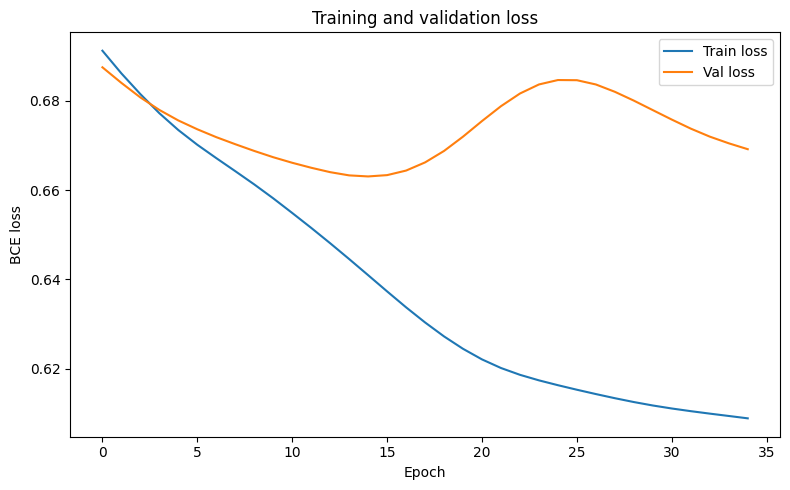

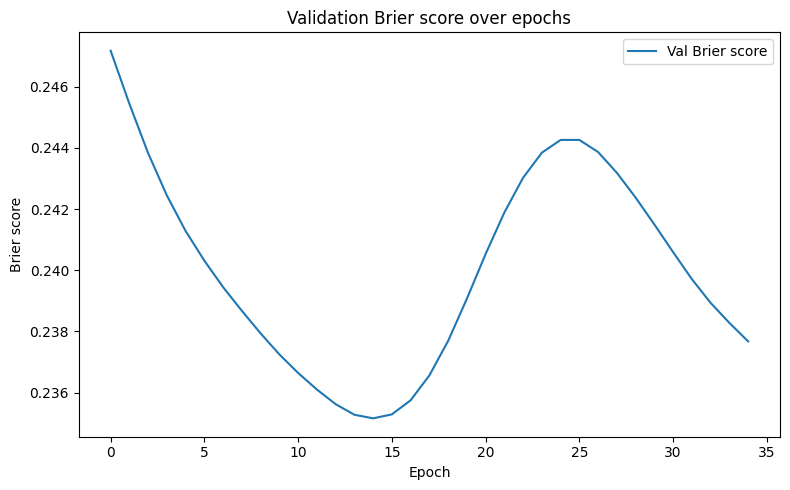

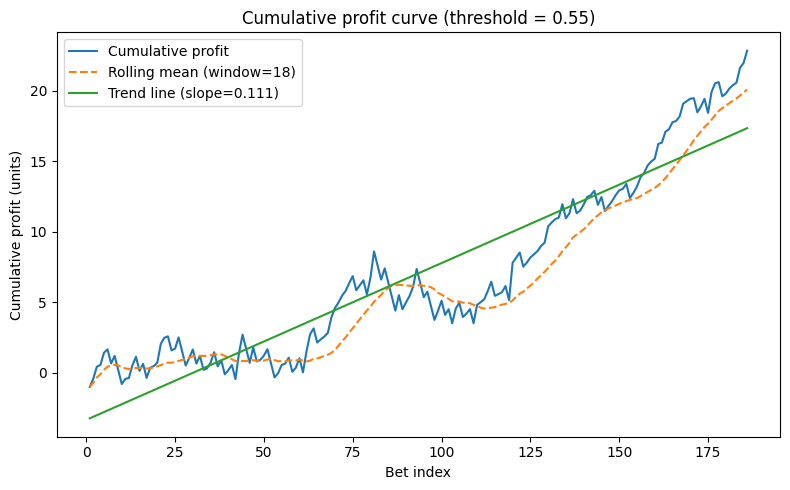

A positive slope (0.111) on the trend line suggests long term profitability at this threshold.


In [ ]:
# Ploting training curves and cumulative profit, saved as PNG files

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_val_loss.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(val_briers, label="Val Brier score")
plt.xlabel("Epoch")
plt.ylabel("Brier score")
plt.title("Validation Brier score over epochs")
plt.legend()
plt.tight_layout()
plt.savefig("val_brier_curve.png", dpi=200, bbox_inches="tight")
plt.show()

if len(cumulative_profit) > 0:
    # Cumulative profit over bet index
    x_axis = np.arange(1, len(cumulative_profit) + 1)
    profit_series = np.array(cumulative_profit, dtype=float)

    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, profit_series, label="Cumulative profit")

    # Rolling average trend line (10 percent window)
    window = max(1, len(profit_series) // 10)
    rolling_avg = pd.Series(profit_series).rolling(window=window, min_periods=1).mean()
    plt.plot(x_axis, rolling_avg, linestyle="--", label=f"Rolling mean (window={window})")

    # Fit and plot linear trend line
    m, b = np.polyfit(x_axis, profit_series, 1)
    trend = m * x_axis + b
    plt.plot(x_axis, trend, label=f"Trend line (slope={m:.3f})")

    plt.xlabel("Bet index")
    plt.ylabel("Cumulative profit (units)")
    plt.title(f"Cumulative profit curve (threshold = {threshold})")
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_cumulative_profit_threshold055.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"A positive slope ({m:.3f}) on the trend line suggests long term profitability at this threshold.")
else:
    print("No bets were placed, so cumulative profit plot is not generated.")
